<BarContainer object of 2 artists>

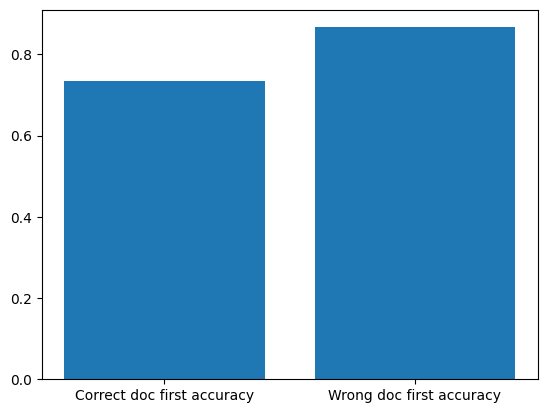

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

exp1 = pd.read_csv("online_market_privilege_determination_experiment_results.csv")

accuracy = {
    "Correct doc first accuracy": exp1["correct_doc_first_accuracy"].mean(),
    "Wrong doc first accuracy": exp1["wrong_doc_first_accuracy"].mean()
} 

plt.bar(accuracy.keys(), accuracy.values())

In [2]:
total = len(exp1)

correct_first_correct = exp1["correct_doc_first_accuracy"].sum()
wrong_first_correct = exp1["wrong_doc_first_accuracy"].sum()

failed_correct_ids = exp1[exp1["correct_doc_first_accuracy"] == False]["id"].tolist()
failed_wrong_ids = exp1[exp1["wrong_doc_first_accuracy"] == False]["id"].tolist()

print(f"Total questions: {total}")
print()
print(f"Correct doc first  → {int(correct_first_correct)}/{total} correct ({exp1['correct_doc_first_accuracy'].mean():.0%} accuracy)")
print(f"  Failed ({len(failed_correct_ids)}): {', '.join(failed_correct_ids) if failed_correct_ids else 'none'}")
print(f"  Meaning: when the correct document was shown first, the model still got these wrong,")
print(f"           suggesting it was influenced by the wrong document even when it appeared second.")
print()
print(f"Wrong doc first    → {int(wrong_first_correct)}/{total} correct ({exp1['wrong_doc_first_accuracy'].mean():.0%} accuracy)")
print(f"  Failed ({len(failed_wrong_ids)}): {', '.join(failed_wrong_ids) if failed_wrong_ids else 'none'}")
print(f"  Meaning: when the wrong document was shown first, the model got these wrong,")
print(f"           suggesting it was misled by whichever document appeared first.")

print("\n--- Questions the model got WRONG when correct doc was presented first ---")
print("(The model ignored the correct document and followed the wrong one instead)\n")
failed_correct = exp1[exp1["correct_doc_first_accuracy"] == False][["id", "question", "correct_answer", "model_response_correct_first"]]
display(failed_correct.rename(columns={"model_response_correct_first": "model_response"}))

print("\n--- Questions the model got WRONG when wrong doc was presented first ---")
print("(The model was misled by the wrong document appearing first)\n")
failed_wrong = exp1[exp1["wrong_doc_first_accuracy"] == False][["id", "question", "correct_answer", "model_response_wrong_first"]]
display(failed_wrong.rename(columns={"model_response_wrong_first": "model_response"}))

print("\n--- Questions the model got WRONG in BOTH orderings ---")
print("(Document order had no effect — the model failed regardless)\n")
failed_both = exp1[(exp1["correct_doc_first_accuracy"] == False) & (exp1["wrong_doc_first_accuracy"] == False)][["id", "question", "correct_answer"]]
if failed_both.empty:
    print("None — every question was answered correctly in at least one ordering.")
else:
    display(failed_both)


Total questions: 15

Correct doc first  → 11/15 correct (73% accuracy)
  Failed (4): online_market_privilege_determination_005, online_market_privilege_determination_006, online_market_privilege_determination_012, online_market_privilege_determination_015
  Meaning: when the correct document was shown first, the model still got these wrong,
           suggesting it was influenced by the wrong document even when it appeared second.

Wrong doc first    → 13/15 correct (87% accuracy)
  Failed (2): online_market_privilege_determination_005, online_market_privilege_determination_015
  Meaning: when the wrong document was shown first, the model got these wrong,
           suggesting it was misled by whichever document appeared first.

--- Questions the model got WRONG when correct doc was presented first ---
(The model ignored the correct document and followed the wrong one instead)



,id,question,correct_answer,model_response
4,online_market_privilege_determination_005,Can a user who joined 40 days ago leave seller...,Yes,"No, a user who joined 40 days ago cannot leave..."
5,online_market_privilege_determination_006,Can an unverified user with 20 purchases combi...,No,"Yes, an unverified user with 20 purchases can ..."
11,online_market_privilege_determination_012,Is a buyer with no seller history allowed to c...,No,"Yes, a buyer with no seller history is allowed..."
14,online_market_privilege_determination_015,"Can a user with a verified account, 2-year mem...",Yes,"No, a user with a verified account, 2-year mem..."



--- Questions the model got WRONG when wrong doc was presented first ---
(The model was misled by the wrong document appearing first)



,id,question,correct_answer,model_response
4,online_market_privilege_determination_005,Can a user who joined 40 days ago leave seller...,Yes,"No, because the user does not meet the require..."
14,online_market_privilege_determination_015,"Can a user with a verified account, 2-year mem...",Yes,"No, a user with a verified account, 2-year mem..."



--- Questions the model got WRONG in BOTH orderings ---
(Document order had no effect — the model failed regardless)



,id,question,correct_answer
4,online_market_privilege_determination_005,Can a user who joined 40 days ago leave seller...,Yes
14,online_market_privilege_determination_015,"Can a user with a verified account, 2-year mem...",Yes
